# Evaluating the 46-class model trained on national dataset.

#### Author: Renuka Sharma (https://huggingface.co/RenukaSharmaAIResearcher)

## Running MegaDetector

This is to get the cropped out bounding boxes from the camera-trap images.

In [1]:
from pathlib import Path
from megadetector.detection import run_detector_batch
import os
import json
import warnings
warnings.filterwarnings('ignore')

input_dir = Path("./images")

output_file = Path("./mg_detections.json")
files = []

for file in os.listdir(os.path.join(input_dir)):
    if not (file.startswith(".") or file.startswith("..")):
        files.append(os.path.join(input_dir, file))

data = run_detector_batch.load_and_run_detector_batch(image_file_names=files, model_file="MDV5A")
with open(output_file, "w") as file:
    json.dump(data, file)

Model v5a.0.1 already exists and is valid at /tmp/megadetector_models/md_v5a.0.1.pt
PyTorch reports 1 available CUDA devices
GPU available: True
PyTorch reports 1 available CUDA devices
GPU available: True
Loading PT detector with compatibility mode classic
Loaded image size 1280 from model metadata
Using model stride: 64
PTDetector using device cuda:0


Fusing layers... 
Model summary: 574 layers, 139990096 parameters, 0 gradients, 207.9 GFLOPs


Loaded model in 3.01 seconds


  0%|          | 0/26 [00:00<?, ?it/s]

Processing image images/Perameles_nasuta_1.JPG


...

 88%|████████▊ | 23/26 [00:03<00:00,  7.38it/s]

Processing image images/Thylogale_stigmatica_2.JPG
Processing image images/Orthonyx_spaldingii_1.JPG


 96%|█████████▌| 25/26 [00:03<00:00,  6.31it/s]

Processing image images/Thylogale_stigmatica_1.JPG
Processing image images/Uromys_caudimaculatus_1.JPG


100%|██████████| 26/26 [00:04<00:00,  6.31it/s]


The results of MegaDetector are stord in the "mg_detections" json file. We will now extract the information from the json file to save the cropped images in a new folder called "cropped_images".

Using MEWC-snip (https://github.com/zaandahl/mewc-snip/blob/main/src/mewc_snip.py) to create the crops. <br> <br>
Variable	Default	Description <br>
INPUT_DIR	"/images/"	A mounted point containing images to process - must match the Docker command above <br>
MD_FILE	"mg_detections.json"	MegaDetector output file <br>
SNIP_DIR	"cropped_images"	A directory to save snips (will be created if it does not exist) <br>
LOWER_CONF	0.05	The lowest detection confidence threshold to accept for snipping <br>
SNIP_SIZE	600	The pixel size for the saved snips (square) <br>

In [2]:
import json
import os
from pathlib import Path
from PIL import Image
import yaml
from tqdm import tqdm

# --------------------
# Utils
# --------------------
def read_yaml(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)

# --------------------
# Load config
# --------------------
config = read_yaml("config.yaml")

for k in config:
    if k in os.environ:
        config[k] = os.environ[k]

INPUT_DIR = Path(config["INPUT_DIR"])
OUTPUT_DIR = Path(config["SNIP_DIR"])
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONF_THRESH = float(config["LOWER_CONF"])
SNIP_SIZE = int(config["SNIP_SIZE"])

# --------------------
# Load MD output
# --------------------
json_path = Path(config["MD_FILE"])

with open(json_path, "r") as f:
    md_data = json.load(f)

print(f"Processing {len(md_data)} images.")

# --------------------
# Main loop (MEWC-snip equivalent)
# --------------------
for entry in md_data:
    img_path = entry["file"]
    # print(img_path)
    if not Path(img_path).exists():
        continue
    detections = entry["detections"]
    
    img = Image.open(img_path)
    width, height = img.size

    max_conf = entry["max_detection_conf"]

    crop_num = 0
    for i, detection in enumerate(detections):
        conf= detection["conf"]
        if detection["category"] != "1":
            continue       

        img = Image.open(img_path).convert("RGB")
        W, H = img.size        

        if conf < CONF_THRESH:
            continue

        x, y, w, h = detection["bbox"]

        left = int(x * W)
        top = int(y * H)
        right = int((x + w) * W)
        bottom = int((y + h) * H)

        crop = img.crop((left, top, right, bottom))

        # Resize rectangular crop
        resized = crop.resize(
            (SNIP_SIZE, SNIP_SIZE),
            Image.BILINEAR
        )

        out_name = (
            f"{Path(img_path).stem}"
            f"-{crop_num}"
            f"{Path(img_path).suffix}"
        )

        resized.save(OUTPUT_DIR / out_name)
        print("Saved the cropped image at", OUTPUT_DIR / out_name)
        crop_num += 1

Processing 26 images.
Saved the cropped image at cropped_images/Perameles_nasuta_1-0.JPG
Saved the cropped image at cropped_images/Hypsiprymnodon_moschatus_2-0.JPG
Saved the cropped image at cropped_images/Alectura_lathami_1-0.JPG
Saved the cropped image at cropped_images/Sus_scrofa_1-0.JPG
Saved the cropped image at cropped_images/Bos_taurus_2-0.JPG
Saved the cropped image at cropped_images/Bos_taurus_2-1.JPG
Saved the cropped image at cropped_images/Bos_taurus_2-2.JPG
Saved the cropped image at cropped_images/Bos_taurus_2-3.JPG
Saved the cropped image at cropped_images/Bos_taurus_2-4.JPG
Saved the cropped image at cropped_images/Bos_taurus_2-5.JPG
Saved the cropped image at cropped_images/Bos_taurus_2-6.JPG
Saved the cropped image at cropped_images/Bos_taurus_2-7.JPG
Saved the cropped image at cropped_images/Heteromyias_cinereifrons_1-0.JPG
Saved the cropped image at cropped_images/Felis_catus_2-0.JPG
Saved the cropped image at cropped_images/Orthonyx_spaldingii_2-0.JPG
Saved the cro

## Running fine-tuned SpeciesNet on National test set

In [3]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [4]:
torch.__version__  # '2.7.0+cu126'

'2.9.1+cu128'

In [5]:
MODEL_PT_PATH = "wildobs_national.pt" # WildObs National model
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


In [6]:
classes = ['Alectura_lathami', 'Antechinus_agilis', 'Bos_taurus', 'Burhinus_grallarius', 'Canis_familiaris', 'Chalcophaps_longirostris', 'Colluricincla_harmonica', 'Corcorax_melanorhamphos', 'Dacelo_novaeguineae', 'Dama_dama', 'Eopsaltria_australis', 'Felis_catus', 'Geopelia_humeralis', 'Gymnorhina_tibicen', 'Homo_sapiens', 'Isoodon_macrourus', 'Lepus_europaeus', 'Macropus_giganteus', 'Menura_novaehollandiae', 'Mus_musculus', 'Oryctolagus_cuniculus', 'Perameles_nasuta', 'Pitta_versicolor', 'Rattus', 'Rattus_fuscipes', 'Rattus_rattus', 'Strepera_graculina', 'Sus_scrofa', 'Tachyglossus_aculeatus', 'Thylogale_stigmatica', 'Trichosurus_caninus', 'Trichosurus_cunninghami', 'Trichosurus_vulpecula', 'Varanus_varius', 'Vombatus_ursinus', 'Vulpes_vulpes', 'Wallabia_bicolor', 'Canis_dingo', 'Capra_hircus', 'Casuarius_casuarius', 'Heteromyias_cinereifrons', 'Hypsiprymnodon_moschatus', 'Megapodius_reinwardt', 'Notamacropus_rufogriseus', 'Orthonyx_spaldingii', 'Uromys_caudimaculatus']

In [7]:
model = torch.load(MODEL_PT_PATH, map_location=DEVICE,weights_only=False)
model.eval()
model.to(DEVICE)

print("Loaded fine-tuned model")


Loaded fine-tuned model


In [8]:
# Transform to be applied on the images before applying the model
transform = transforms.Compose([
    transforms.Resize((480, 480)),
    transforms.ToTensor(),
])

#### Classifier before applying geo-prior

In [9]:
@torch.no_grad()
def classify_image(image_path):

    img = Image.open(image_path).convert("RGB")

    # show the image
    plt.imshow(img)
    plt.axis('off')
    plt.title(image_path)
    plt.show()

    img = transform(img)           # -> C,H,W
    img = img.unsqueeze(0)         # -> B,C,H,W
    img = img.permute(0,2,3,1)     # -> B,H,W,C

    img = img.to(DEVICE)

    logits = model(img)
    probs = torch.softmax(logits, dim=1)[0].cpu().numpy()

    # sort by confidence
    order = np.argsort(probs)[::-1]

    print("\n---- PREDICTIONS ----")
    for idx in order:
        label = classes[idx]
        confidence = probs[idx]
        print(f"{label:<25}  {confidence:.4f}")

    best_idx = order[0]
    print("\n FINAL PREDICTION:")
    print(f"Species: {classes[best_idx]}")
    print(f"Confidence: {probs[best_idx]:.4f}")


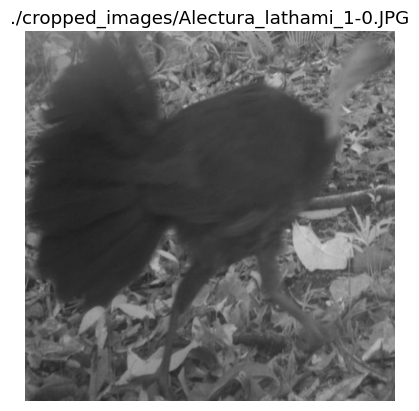


---- PREDICTIONS ----
Alectura_lathami           0.9999
Megapodius_reinwardt       0.0001
Casuarius_casuarius        0.0000
Heteromyias_cinereifrons   0.0000
Hypsiprymnodon_moschatus   0.0000
Canis_familiaris           0.0000
Orthonyx_spaldingii        0.0000
Sus_scrofa                 0.0000
Felis_catus                0.0000
Varanus_varius             0.0000
Canis_dingo                0.0000
Corcorax_melanorhamphos    0.0000
Thylogale_stigmatica       0.0000
Uromys_caudimaculatus      0.0000
Notamacropus_rufogriseus   0.0000
Perameles_nasuta           0.0000
Capra_hircus               0.0000
Lepus_europaeus            0.0000
Dama_dama                  0.0000
Trichosurus_cunninghami    0.0000
Homo_sapiens               0.0000
Tachyglossus_aculeatus     0.0000
Vulpes_vulpes              0.0000
Menura_novaehollandiae     0.0000
Oryctolagus_cuniculus      0.0000
Rattus_rattus              0.0000
Geopelia_humeralis         0.0000
Dacelo_novaeguineae        0.0000
Pitta_versicolor         

In [10]:
# To avoid the user warning while showing the images
# UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown  plt.show()
%matplotlib inline 
# TEST_IMAGE_PATH = "./cropped_images/Casuarius_casuarius_1-0.JPG"
TEST_IMAGE_PATH = "./cropped_images/Alectura_lathami_1-0.JPG"
# TEST_IMAGE_PATH = "./cropped_images/Perameles_nasuta_1-0.JPG"

classify_image(TEST_IMAGE_PATH)

We can see the final prediction here.

#### Accompanying functions for geo-prior addition

In [11]:
import pandas as pd
species_state = pd.read_csv("species_per_state.csv")
total = len(classes)

def normalise_name(x):
    return str(x).strip().lower().replace("_", " ")

def build_state_species_map(species_state):
    state_map = {}
    for state in species_state.columns:
        species = (
            species_state[state]
            .dropna()
            .map(normalise_name)
            .tolist()
        )
        state_map[state] = set(species)
    return state_map

state_species = build_state_species_map(species_state)

def make_geo_prior(labels, state, in_state_weight=1.0, out_state_weight=0.2):
    """
    labels: list like ["Alectura lathami", "Antechinus agilis", ...]
    state: e.g. "Queensland"
    """
    found = 0
    allowed_species = state_species[state]

    prior = []
    for label in labels:
        sci_name = normalise_name(label)
        if sci_name in allowed_species:
            prior.append(in_state_weight)
            print("Found", sci_name)
            found += 1
        else:
            prior.append(out_state_weight)
    print("prior=", prior)

    prior = np.array(prior, dtype=float)
    prior = prior / prior.sum()
    print("Found", found, "out of", total, "scientific names.")
    return prior

def apply_geo_prior(image_probs, labels, state, alpha=0.2):
    """
    alpha controls how strongly location affects prediction.
    alpha=0 means image only.
    alpha=1 means full geo-prior multiplication.
    """
    geo_prior = make_geo_prior(labels, state)
    # print("geo prior=", geo_prior)

    adjusted = image_probs * (geo_prior ** alpha)
    adjusted = adjusted / adjusted.sum()

    return adjusted

#### Classifier with geo-prior 

In [12]:
@torch.no_grad()
def classify_image(image_path):

    img = Image.open(image_path).convert("RGB")

    # show the image
    plt.imshow(img)
    plt.axis('off')
    plt.title(image_path)
    # plt.show()

    img = transform(img)           # -> C,H,W
    img = img.unsqueeze(0)         # -> B,C,H,W
    img = img.permute(0,2,3,1)     # -> B,H,W,C

    img = img.to(DEVICE)

    logits = model(img)
    probs = torch.softmax(logits, dim=1)[0].cpu().numpy() # raw probabilities
    # sort by confidence
    order = np.argsort(probs)[::-1]
    state = "Queensland"

    # Apply geo-prior
    after_geo_prior_prob = apply_geo_prior(probs, classes, state, alpha=1.0)
    # print("prob=", probs)
    # print("after geo prior=", after_geo_prior_prob)
    # print("classes=", classes)

    # Compare probabilities side-by-side
    comparison = []
    for idx, label in enumerate(classes):
        raw_prob = probs[idx]
        geo_prob = after_geo_prior_prob[idx]
        diff = geo_prob - raw_prob

        comparison.append((label, raw_prob, geo_prob, diff))

    # Sort by geo-prior probability, descending
    comparison.sort(key=lambda x: x[2], reverse=True)

    print(f"\n---- PROBABILITY COMPARISON: w/o geo-prior vs with geo-prior ({state}) ----")
    print(f"{'Species':<25} {'No Geo':>10} {'With Geo':>10} {'Change':>10}")
    print("-" * 60)

    for label, raw_prob, geo_prob, diff in comparison:
        print(f"{label:<25} {raw_prob:>10.4f} {geo_prob:>10.4f} {diff:>+10.4f}")

    # Best without geo-prior
    raw_best_idx = np.argmax(probs)

    print("\nFINAL PREDICTION w/o geo-prior:")
    print(f"Species: {classes[raw_best_idx]}")
    print(f"Confidence: {probs[raw_best_idx]:.4f}")

    # Best with geo-prior
    geo_best_idx = np.argmax(after_geo_prior_prob)

    print("\nFINAL PREDICTION with geo-prior:")
    print(f"Species: {classes[geo_best_idx]}")
    print(f"Confidence: {after_geo_prior_prob[geo_best_idx]:.4f}")



IMAGE: cropped_images/Bos_taurus_1-3.JPG
Found canis familiaris
Found isoodon macrourus
Found macropus giganteus
Found perameles nasuta
Found rattus fuscipes
Found tachyglossus aculeatus
Found thylogale stigmatica
Found trichosurus caninus
Found trichosurus vulpecula
Found wallabia bicolor
Found hypsiprymnodon moschatus
Found notamacropus rufogriseus
Found uromys caudimaculatus
prior= [0.2, 0.2, 0.2, 0.2, 1.0, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 1.0, 0.2, 1.0, 0.2, 0.2, 0.2, 1.0, 0.2, 0.2, 1.0, 0.2, 0.2, 0.2, 1.0, 1.0, 1.0, 0.2, 1.0, 0.2, 0.2, 0.2, 1.0, 0.2, 0.2, 0.2, 0.2, 1.0, 0.2, 1.0, 0.2, 1.0]
Found 13 out of 46 scientific names.

---- PROBABILITY COMPARISON: w/o geo-prior vs with geo-prior (Queensland) ----
Species                       No Geo   With Geo     Change
------------------------------------------------------------
Bos_taurus                    0.9985     0.9926    -0.0059
Canis_familiaris              0.0015     0.0074    +0.0059
Felis_catus              

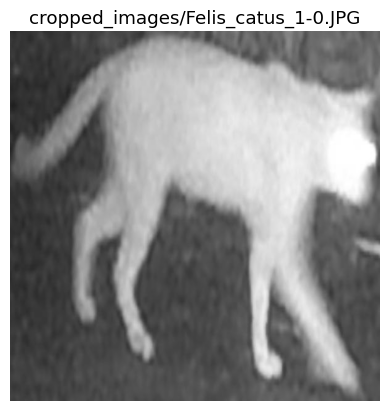

In [13]:
IMAGE_FOLDER = "./cropped_images"

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

image_paths = [
    p for p in Path(IMAGE_FOLDER).iterdir()
    if p.suffix.lower() in image_extensions
]

for image_path in image_paths:
    print("\n" + "=" * 80)
    print(f"IMAGE: {image_path}")
    print("=" * 80)

    classify_image(str(image_path))